# Step 6: Fixed Source, Fixed PSF/Point Source, Stellar M/L + gNFW


In [1]:
import os
os.environ.setdefault('HDF5_USE_FILE_LOCKING', 'FALSE')
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

from pathlib import Path
import warnings
warnings.simplefilter('ignore')

import xarray as xr
from scipy.optimize import least_squares

from herculens_import_main import *
from lens_images_extension import LensImageExtension
from herculens.PointSourceModel.point_source_model import PointSourceModel
from herculens.MassModel import mass_model_base
from jax_lensing_profiles.MassModel.Profiles.CuspyNFW_ellipse_kappa import CuspyNFW_3D_fn
from jax_lensing_profiles.MassModel.Profiles.MGE import MGE

jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()


[CudaDevice(id=0)]


In [2]:
class CuspyNFWEllipseKappa(MGE):
    def __init__(self):
        super().__init__(
            CuspyNFW_3D_fn,
            'R_s',
            n_gauss=20,
            n_terms=28,
            sigma_start_mult=1/200,
            sigma_end_mult=20,
            three_d=True,
        )

mass_model_base.STRING_MAPPING['CUSPY_NFW_ELLIPSE_KAPPA'] = CuspyNFWEllipseKappa

suffix = '_ss=2_full_light_multimass'
run_tag = '20260401_11'
OUTPUT_ROOT = Path('/mnt/lustre/tianli/quasar_hmc')
RUN_OUTPUT_DIR = OUTPUT_ROOT / f'WFI2033{suffix}_{run_tag}'
RESULT_DIR = Path(f'./result/result{suffix}_{run_tag}')
PRODUCTS_DIR = RESULT_DIR / 'data_products'
DATA_DIR = Path('../../Data/WFI2033')
RAW_DATA_PATH = DATA_DIR / 'jw01198-o004_t004_nircam_clear-f115w_i2d.fits'
DATA_SUB_PATH = RESULT_DIR / f'data_minus_lens_light{suffix}.fits'
HMC_ALL_PATH = RUN_OUTPUT_DIR / f'WFI2033_all{suffix}.nc'
FIXED_FIRST_THREE_PATH = RUN_OUTPUT_DIR / f'fixed_first_three_gaussians{suffix}.npz'

with fits.open(RAW_DATA_PATH, memmap=True) as hdul_raw:
    raw_header = hdul_raw['SCI'].header if 'SCI' in hdul_raw else hdul_raw[0].header
    exposure_time = float(raw_header.get('EXPTIME', raw_header.get('TEXPTIME', raw_header.get('XPOSURE', 1.0))))
pix_scale = float(np.sqrt(raw_header['PIXAR_A2']))

data = np.array(fits.getdata(PRODUCTS_DIR / f'data_bkg_sub{suffix}.fits'), dtype=float)
data_subtracted = np.array(fits.getdata(DATA_SUB_PATH), dtype=float)
rms_file = np.array(fits.getdata(PRODUCTS_DIR / f'rms_with_psf_extra{suffix}.fits'), dtype=float)
mask_out = np.array(fits.getdata(DATA_DIR / 'mask_out_center.fits'), dtype=bool)
fixed_first_three = np.load(FIXED_FIRST_THREE_PATH)
inf_data_step5 = az.from_netcdf(HMC_ALL_PATH)
HMC_posterior = inf_data_step5.posterior
HMC_last = HMC_posterior.isel(draw=-1)
HMC_reference = HMC_last.median(dim='chain')

ny, nx = mask_out.shape
xc, yc = nx / 2, ny / 2
r = 16
Y, X = np.indices((ny, nx))
mask_out = np.logical_or(mask_out, (X - xc) ** 2 + (Y - yc) ** 2 <= r ** 2)

pixel_grid_shape = 74
source_grid_scale = 0.8
ss_factor = 2
num_chains = int(HMC_last.sizes['chain'])

POINT_SOURCE_PRIOR = {
    'pos_sigma': 0.05,
    'pos_window': 0.2,
    'log10_amp_low': -3.0,
    'log10_amp_high': 4.5,
}

CONJUGATE_POINT_PRIOR = {
    'rate': 1000.0,
}

PSF_CORR_PRIOR = {
    'sigma_log': 1.0,
    'log_clip': 5.0,
}

SOURCE_GRID_PRIOR = {
    'plate_name': 'Source grid',
    'param_name': 'source_grid',
    'sigma_low': 1e-5,
    'sigma_high': 10,
    'n_high': 100,
    'positive': True,
}

G1_MASS_CENTER = (1.556, 1.299)
G2_MASS_CENTER = (2.145, -3.326)
G3_MASS_CENTER = (4.243403, 6.185564)
G7_MASS_CENTER = (-7.284665, -10.319681)
conj_points = jnp.array([
    [1.20212170716053, -0.12271885209256231],
    [0.9053233071260114, 0.5277189685977776],
    [-1.0461673774453952, 1.0081083299749878],
    [-0.1255456241215261, -0.8965524340129204],
])

k_values = K_grid((pixel_grid_shape, pixel_grid_shape)).k


def build_psf_corr_factor_field(log_psf_corr_center, psf_shape, log_clip=PSF_CORR_PRIOR['log_clip']):
    ny, nx = psf_shape
    log_field = jnp.asarray(log_psf_corr_center)
    if log_field.shape != (ny, nx):
        raise ValueError(f'log_psf_corr_center shape {log_field.shape} does not match psf shape {(ny, nx)}')
    return jnp.exp(jnp.clip(log_field, -log_clip, log_clip))


def build_corrected_psf_kernel(psf_base, log_psf_corr_center, eps=1e-12):
    corr_field = build_psf_corr_factor_field(log_psf_corr_center, jnp.asarray(psf_base).shape)
    psf_eff = jnp.asarray(psf_base) * corr_field
    psf_eff = jnp.maximum(psf_eff, eps)
    return psf_eff / (jnp.sum(psf_eff) + eps)


In [3]:
output_path = Path('./data/mask_out_center_r16.fits')
fits.writeto(output_path, mask_out.astype(np.uint8), overwrite=True)

print('Saved to:', output_path)

Saved to: data/mask_out_center_r16.fits


In [4]:
fixed_inner_three = [{
    'amp': np.array(fixed_first_three['amp'], dtype=float),
    'sigma': np.array(fixed_first_three['sigma'], dtype=float),
    'e1': np.array(fixed_first_three['e1'], dtype=float),
    'e2': np.array(fixed_first_three['e2'], dtype=float),
    'center_x': np.array(fixed_first_three['center_x'], dtype=float),
    'center_y': np.array(fixed_first_three['center_y'], dtype=float),
}]

outer_two = [{
    'amp': np.array(HMC_reference['amp_lens'].values, dtype=float)[-2:],
    'sigma': np.array(HMC_reference['sigma_lens'].values, dtype=float)[-2:],
    'e1': np.array(HMC_reference['e_lens'].values, dtype=float)[0, -2:],
    'e2': np.array(HMC_reference['e_lens'].values, dtype=float)[1, -2:],
    'center_x': np.array(HMC_reference['center_lens'].values, dtype=float)[0, -2:],
    'center_y': np.array(HMC_reference['center_lens'].values, dtype=float)[1, -2:],
}]

full_lens_light = [{
    k: np.concatenate([np.asarray(fixed_inner_three[0][k]), np.asarray(outer_two[0][k])])
    for k in ('amp', 'sigma', 'e1', 'e2', 'center_x', 'center_y')
}]

fixed_point_source = [{
    'ra': np.array(HMC_reference['ra_ps'].values, dtype=float),
    'dec': np.array(HMC_reference['dec_ps'].values, dtype=float),
    'amp': np.power(10.0, np.array(HMC_reference['log10_amp_ps'].values, dtype=float)),
}]

fixed_psf = np.array(HMC_reference['psf_kernel_corrected'].values, dtype=float)
fixed_psf = np.clip(fixed_psf, 0.0, None)
fixed_psf = fixed_psf / fixed_psf.sum()

epl_center = np.array(HMC_reference['center_1'].values, dtype=float).reshape(2,)


def chain_array(name, i):
    return HMC_last[name].isel(chain=i).values


fixed_sis_g1 = [{
    'theta_E': float(np.asarray(HMC_reference['theta_E_g1'].values).reshape(-1)[0]),
    'center_x': float(G1_MASS_CENTER[0]),
    'center_y': float(G1_MASS_CENTER[1]),
}]
fixed_sis_g2 = [{
    'theta_E': float(np.asarray(HMC_reference['theta_E_g2'].values).reshape(-1)[0]),
    'center_x': float(G2_MASS_CENTER[0]),
    'center_y': float(G2_MASS_CENTER[1]),
}]
fixed_sis_g3 = [{
    'theta_E': 0.088,
    'center_x': float(G3_MASS_CENTER[0]),
    'center_y': float(G3_MASS_CENTER[1]),
}]
fixed_sis_g7 = [{
    'theta_E': 0.388,
    'center_x': float(G7_MASS_CENTER[0]),
    'center_y': float(G7_MASS_CENTER[1]),
}]

pixel_grid, xgrid, ygrid, x_axis, y_axis, extent, nx, ny = get_pixel_grid(jnp.asarray(data_subtracted), pix_scale)
noise = Noise(nx, ny, exposure_time=exposure_time)
psf_obj = PSF(psf_type='PIXEL', kernel_point_source=fixed_psf)

mass_model_step6 = MassModel([
    'MULTI_GAUSSIAN_ELLIPSE_KAPPA',
    'CUSPY_NFW_ELLIPSE_KAPPA',
    'SHEAR',
    'SIS',
    'SIS',
    'SIS',
    'SIS',
])
source_light_model = LightModel(
    ['PIXELATED'],
    pixel_adaptive_grid=True,
    pixel_interpol='fast_bilinear',
    kwargs_pixelated={'num_pixels': pixel_grid_shape},
)
point_source_model = PointSourceModel(
    ['IMAGE_POSITIONS'],
    mass_model=mass_model_step6,
    image_plane=deepcopy(pixel_grid),
)
lens_image_step6 = LensImageExtension(
    deepcopy(pixel_grid),
    psf_obj,
    noise_class=noise,
    lens_light_model_class=LightModel(['MULTI_GAUSSIAN_ELLIPSE'], {}),
    lens_mass_model_class=mass_model_step6,
    source_model_class=source_light_model,
    point_source_model_class=point_source_model,
    source_arc_mask=jnp.array(mask_out),
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale=source_grid_scale,
)


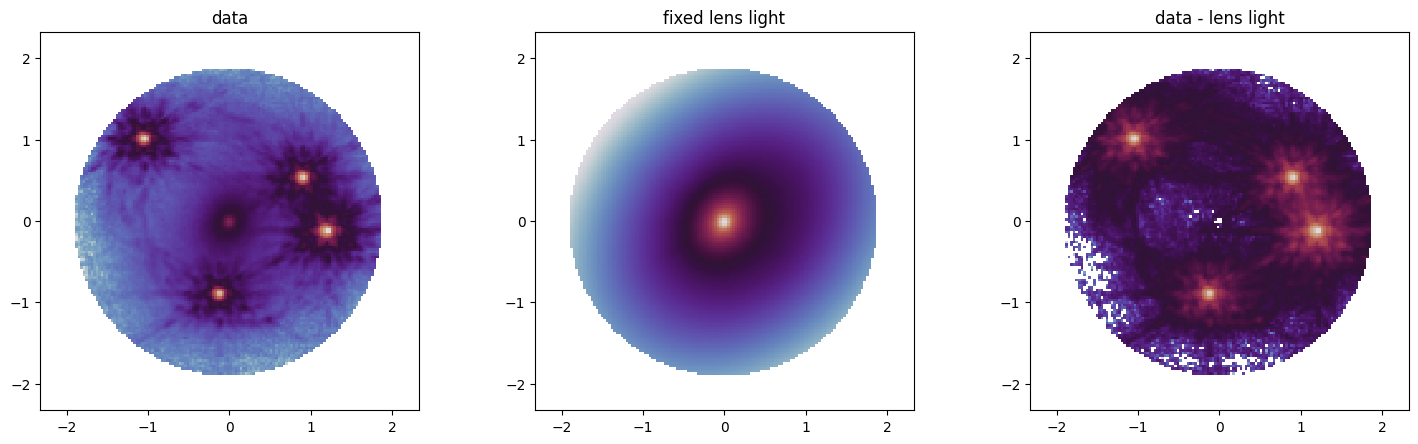

In [5]:
lens_light_image = np.array(data - data_subtracted, dtype=float)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].imshow(np.ma.array(data, mask=~mask_out), origin='lower', extent=extent, cmap='twilight', norm='log')
ax[0].set_title('data')
ax[1].imshow(np.ma.array(lens_light_image, mask=~mask_out), origin='lower', extent=extent, cmap='twilight', norm='log')
ax[1].set_title('fixed lens light')
ax[2].imshow(np.ma.array(data_subtracted, mask=~mask_out), origin='lower', extent=extent, cmap='twilight', norm='log')
ax[2].set_title('data - lens light')
plt.tight_layout()
plt.show()


In [6]:
epl_mass_model = MassModel(['EPL'])
star_nfw_mass_model = MassModel(['MULTI_GAUSSIAN_ELLIPSE_KAPPA', 'CUSPY_NFW_ELLIPSE_KAPPA'])

SIS_PRIORS = {
    'g1': {
        'plate_name': 'Lens mass g1',
        'param_name': 'g1',
        'origin': G1_MASS_CENTER,
        'theta_low': 0.0,
        'theta_high': 0.25,
    },
    'g2': {
        'plate_name': 'Lens mass g2',
        'param_name': 'g2',
        'origin': G2_MASS_CENTER,
        'theta_mean': 0.622,
        'theta_low': 0.5,
        'theta_high': 0.7,
    },
    'g3': {
        'origin': G3_MASS_CENTER,
        'theta_mean': 0.088,
    },
    'g7': {
        'origin': G7_MASS_CENTER,
        'theta_mean': 0.388,
    },
}


def scale_theta_E_from_g2(theta_E_g2, target_prior):
    return theta_E_g2 * target_prior['theta_mean'] / SIS_PRIORS['g2']['theta_mean']


FIXED_SIS_THETA_E = {
    'g1': float(np.asarray(HMC_reference['theta_E_g1'].values).reshape(-1)[0]),
    'g2': float(np.asarray(HMC_reference['theta_E_g2'].values).reshape(-1)[0]),
    'g3': 0.088,
    'g7': 0.388,
}


def target_epl_kwargs_for_chain(i):
    center_i = np.asarray(chain_array('center_1', i), dtype=float).reshape(2,)
    e_i = np.asarray(chain_array('e_1', i), dtype=float).reshape(2, -1)
    return [{
        'theta_E': float(np.asarray(chain_array('theta_E_1', i)).reshape(-1)[0]),
        'gamma': float(np.asarray(chain_array('gamma_1', i)).reshape(-1)[0]),
        'e1': float(e_i[0, 0]),
        'e2': float(e_i[1, 0]),
        'center_x': float(center_i[0]),
        'center_y': float(center_i[1]),
    }]


def scaled_mass_from_light(m2l_ratio):
    mass_from_light = deepcopy(full_lens_light)
    amp = jnp.asarray(mass_from_light[0]['amp'])
    mass_from_light[0]['amp'] = amp * jnp.asarray(m2l_ratio, dtype=jnp.float64) / jnp.sum(amp)
    return mass_from_light


def build_star_nfw_kwargs_ls(m2l_ratio, kappa_s_halo, e1_halo, e2_halo, center_i):
    mass_from_light = scaled_mass_from_light(m2l_ratio)
    halo = {
        'R_s': 5.0,
        'gamma': 1.0,
        'kappa_s': float(kappa_s_halo),
        'e1': float(e1_halo),
        'e2': float(e2_halo),
        'center_x': float(center_i[0]),
        'center_y': float(center_i[1]),
    }
    return mass_from_light + [halo]


def build_step6_mass_init(i):
    center_i = np.asarray(chain_array('center_1', i), dtype=float).reshape(2,)
    target_epl_kwargs_i = target_epl_kwargs_for_chain(i)
    target_epl_kappa_i = np.array(epl_mass_model.kappa(xgrid, ygrid, target_epl_kwargs_i), dtype=float)

    def ls_residual(theta):
        model_kappa = np.array(
            star_nfw_mass_model.kappa(
                xgrid,
                ygrid,
                build_star_nfw_kwargs_ls(theta[0], theta[1], theta[2], theta[3], center_i),
            ),
            dtype=float,
        )
        return (model_kappa - target_epl_kappa_i)[mask_out].ravel()

    ls_x0 = np.array([
        2.0,
        0.1,
        target_epl_kwargs_i[0]['e1'],
        target_epl_kwargs_i[0]['e2'],
    ], dtype=float)
    ls_result = least_squares(
        ls_residual,
        x0=ls_x0,
        bounds=([0.0, 0.0, -0.2, -0.2], [14.0, 1.0, 0.2, 0.2]),
    )
    init_i = {
        'm2l_ratio': jnp.asarray(ls_result.x[0], dtype=jnp.float64),
        'kappa_s_halo': jnp.asarray(ls_result.x[1], dtype=jnp.float64),
        'gammain_halo': jnp.asarray(1.0, dtype=jnp.float64),
        'e_halo': jnp.asarray(ls_result.x[2:4], dtype=jnp.float64),
    }
    return init_i, ls_result


STEP6_MASS_INITS = []
STEP6_LS_RESULTS = []
for i in range(num_chains):
    init_i, ls_result_i = build_step6_mass_init(i)
    STEP6_MASS_INITS.append(init_i)
    STEP6_LS_RESULTS.append(ls_result_i)
    print(
        f'chain {i}: '
        f'm2l_ratio={float(ls_result_i.x[0]):.4f}, '
        f'kappa_s_halo={float(ls_result_i.x[1]):.4f}, '
        f'e1={float(ls_result_i.x[2]):.4f}, '
        f'e2={float(ls_result_i.x[3]):.4f}, '
        f'success={bool(ls_result_i.success)}, '
        f'cost={float(ls_result_i.cost):.4f}'
    )


STEP1_BASE_KWARGS = {
    'label': 'step1',
    'gnfw_kwargs': {
        'gamma_in_up': 1.4,
        'gamma_in_low': 0.6,
        'Rs_value': 5.0,
        'sph': False,
        'gamma_sheer_low': -0.5,
        'gamma_sheer_high': 0.5,
    },
    'fixed_sis_theta_E': FIXED_SIS_THETA_E,
    'free_sis': (),
    'scale_with_g2': False,
    'free_point_source': False,
    'enable_psf_corr': False,
    'use_conjugate_prior': False,
    'compute_fermat_diffs': False,
}


def build_step1_stage_kwargs(i):
    center_i = np.asarray(chain_array('center_1', i), dtype=float).reshape(2,)
    shear_i = np.asarray(chain_array('gamma_sheer_1', i), dtype=float).reshape(2,)
    return STEP1_BASE_KWARGS | {
        'gnfw_kwargs': STEP1_BASE_KWARGS['gnfw_kwargs'] | {
            'center_x': float(center_i[0]),
            'center_y': float(center_i[1]),
            'gamma_sheer_value': shear_i,
        }
    }


STEP2_KWARGS = {
    'label': 'step2',
    'gnfw_kwargs': {
        'gamma_in_up': 1.4,
        'gamma_in_low': 0.6,
        'Rs_low': 2,
        'Rs_high': 20.0,
        'sph': False,
        'gamma_sheer_low': -0.5,
        'gamma_sheer_high': 0.5,
    },
    'fixed_sis_theta_E': {},
    'free_sis': ('g1', 'g2'),
    'scale_with_g2': True,
    'free_point_source': True,
    'enable_psf_corr': True,
    'use_conjugate_prior': True,
    'compute_fermat_diffs': True,
}


Least-squares init:
  m2l_ratio   = 1.5542417721260522
  kappa_s_halo= 0.17516081543124715
  success     = True
  cost        = 97.52457964085403


In [7]:
def fixed_sis(theta_E, origin):
    return [{
        'theta_E': theta_E,
        'center_x': float(origin[0]),
        'center_y': float(origin[1]),
    }]


def build_stage_sis(stage_kwargs):
    sis_mass = []
    for name, theta_E in stage_kwargs['fixed_sis_theta_E'].items():
        sis_mass += fixed_sis(theta_E, SIS_PRIORS[name]['origin'])

    if 'g1' in stage_kwargs['free_sis']:
        sis_mass += SIS(**SIS_PRIORS['g1'])

    if 'g2' in stage_kwargs['free_sis']:
        g2_mass = SIS(**SIS_PRIORS['g2'])
        sis_mass += g2_mass
        if stage_kwargs['scale_with_g2']:
            theta_E_g2 = g2_mass[0]['theta_E']
            theta_E_g3 = numpyro.deterministic('theta_E_g3', scale_theta_E_from_g2(theta_E_g2, SIS_PRIORS['g3']))
            theta_E_g7 = numpyro.deterministic('theta_E_g7', scale_theta_E_from_g2(theta_E_g2, SIS_PRIORS['g7']))
            sis_mass += fixed_sis(theta_E_g3, G3_MASS_CENTER)
            sis_mass += fixed_sis(theta_E_g7, G7_MASS_CENTER)

    return sis_mass


def build_stage_point_source(stage_kwargs):
    if not stage_kwargs['free_point_source']:
        return fixed_point_source

    n_ps = conj_points.shape[0]
    ra_ps = numpyro.sample(
        'ra_ps',
        dist.TruncatedNormal(
            loc=conj_points[:, 0],
            scale=POINT_SOURCE_PRIOR['pos_sigma'],
            low=conj_points[:, 0] - POINT_SOURCE_PRIOR['pos_window'],
            high=conj_points[:, 0] + POINT_SOURCE_PRIOR['pos_window'],
        ),
    )
    dec_ps = numpyro.sample(
        'dec_ps',
        dist.TruncatedNormal(
            loc=conj_points[:, 1],
            scale=POINT_SOURCE_PRIOR['pos_sigma'],
            low=conj_points[:, 1] - POINT_SOURCE_PRIOR['pos_window'],
            high=conj_points[:, 1] + POINT_SOURCE_PRIOR['pos_window'],
        ),
    )
    log10_amp_ps = numpyro.sample(
        'log10_amp_ps',
        dist.Uniform(
            POINT_SOURCE_PRIOR['log10_amp_low'],
            POINT_SOURCE_PRIOR['log10_amp_high'],
        ).expand([n_ps]),
    )
    return [{
        'ra': ra_ps,
        'dec': dec_ps,
        'amp': jnp.power(10.0, log10_amp_ps),
    }]


def build_stage_psf(stage_kwargs):
    psf_base = jnp.asarray(fixed_psf)
    corr_field = jnp.ones_like(psf_base)
    psf_kernel = psf_base

    if stage_kwargs['enable_psf_corr']:
        log_psf_corr_center = numpyro.sample(
            'log_psf_corr_center',
            dist.Normal(0.0, PSF_CORR_PRIOR['sigma_log']).expand(psf_base.shape),
        )
        corr_field = build_psf_corr_factor_field(log_psf_corr_center, psf_base.shape)
        psf_kernel = build_corrected_psf_kernel(psf_base, log_psf_corr_center)

    numpyro.deterministic('psf_corr_factor_field', corr_field)
    numpyro.deterministic('psf_kernel_corrected', psf_kernel)
    return psf_kernel


def maybe_add_conjugate_prior(stage_kwargs, kwargs_lens, kwargs_point_source):
    if not stage_kwargs['use_conjugate_prior']:
        return
    src_x_ps, src_y_ps = lens_image_step6.MassModel.ray_shooting(
        kwargs_point_source[0]['ra'],
        kwargs_point_source[0]['dec'],
        kwargs_lens,
    )
    conj_points_model = jnp.stack([src_x_ps, src_y_ps], axis=1)
    conj_distance = reduced_distance_matrix(conj_points_model)
    nc = conj_distance.shape[0]
    with numpyro.plate(f'Conjugate points 2 - [{nc}]', nc):
        numpyro.sample('conjugate_points', dist.Exponential(CONJUGATE_POINT_PRIOR['rate']), obs=conj_distance)


def model_step6(data_subtracted, stage_kwargs):
    m2l_ratio = numpyro.sample('m2l_ratio', dist.Uniform(0.0, 3.0))
    gnfw_shear = GNFW_w_shear(
        'Lens mass',
        'halo',
        **stage_kwargs['gnfw_kwargs'],
    )
    kwargs_source = [
        matern_power_spectrum(
            k=k_values,
            **SOURCE_GRID_PRIOR,
        )
    ]
    kwargs_lens = scaled_mass_from_light(m2l_ratio) + gnfw_shear + build_stage_sis(stage_kwargs)
    kwargs_point_source = build_stage_point_source(stage_kwargs)
    maybe_add_conjugate_prior(stage_kwargs, kwargs_lens, kwargs_point_source)

    if stage_kwargs['compute_fermat_diffs']:
        fermat = lens_image_step6.MassModel.fermat_potential(
            kwargs_point_source[0]['ra'],
            kwargs_point_source[0]['dec'],
            kwargs_lens,
        )
        numpyro.deterministic('fermat_potential_images', fermat)
        numpyro.deterministic('fpd_31', fermat[2] - fermat[0])
        numpyro.deterministic('fpd_32', fermat[2] - fermat[1])
        numpyro.deterministic('fpd_34', fermat[2] - fermat[3])

    psf_kernel = build_stage_psf(stage_kwargs)

    model_image = lens_image_step6.model(
        kwargs_lens=kwargs_lens,
        kwargs_source=kwargs_source,
        kwargs_lens_light=[],
        kwargs_point_source=kwargs_point_source,
        source_add=True,
        lens_light_add=False,
        point_source_add=True,
        psf_kernel=psf_kernel,
    )
    numpyro.deterministic('model_image', model_image)

    with numpyro.plate(f'data - [{int(mask_out.sum())}]', int(mask_out.sum())):
        numpyro.sample('obs', dist.Normal(model_image[mask_out], jnp.asarray(rms_file)[mask_out]), obs=jnp.asarray(data_subtracted)[mask_out])


def evaluate_step6(params, stage_kwargs):
    seeded = numpyro.handlers.seed(model_step6, jax.random.PRNGKey(0))
    substituted = numpyro.handlers.substitute(seeded, data=params)
    trace = numpyro.handlers.trace(substituted).get_trace(data_subtracted, stage_kwargs)
    fermat_diffs = None
    if stage_kwargs['compute_fermat_diffs']:
        fermat_diffs = {
            'fpd_31': float(np.asarray(trace['fpd_31']['value'])),
            'fpd_32': float(np.asarray(trace['fpd_32']['value'])),
            'fpd_34': float(np.asarray(trace['fpd_34']['value'])),
        }
    return (
        np.array(trace['model_image']['value']),
        np.array(trace['pixels_source_grid']['value']),
        np.array(trace['psf_kernel_corrected']['value']),
        fermat_diffs,
    )


def build_source_init_values(i):
    return {
        'n_source_grid': jnp.asarray(chain_array('n_source_grid', i), dtype=jnp.float64),
        'sigma_source_grid': jnp.asarray(chain_array('sigma_source_grid', i), dtype=jnp.float64),
        'rho_source_grid': jnp.asarray(chain_array('rho_source_grid', i), dtype=jnp.float64),
        'pixels_wn_source_grid': jnp.asarray(chain_array('pixels_wn_source_grid', i), dtype=jnp.float64),
    }


def build_step1_init_values(i):
    return build_source_init_values(i) | STEP6_MASS_INITS[i]


def build_step2_extra_init(i):
    return {
        'Rs_halo': jnp.asarray(5.0, dtype=jnp.float64),
        'center_halo': jnp.asarray(chain_array('center_1', i), dtype=jnp.float64).reshape(2,),
        'theta_E_g1': jnp.asarray(chain_array('theta_E_g1', i), dtype=jnp.float64),
        'theta_E_g2': jnp.asarray(chain_array('theta_E_g2', i), dtype=jnp.float64),
        'ra_ps': jnp.asarray(chain_array('ra_ps', i), dtype=jnp.float64),
        'dec_ps': jnp.asarray(chain_array('dec_ps', i), dtype=jnp.float64),
        'log10_amp_ps': jnp.asarray(chain_array('log10_amp_ps', i), dtype=jnp.float64),
        'log_psf_corr_center': jnp.asarray(chain_array('log_psf_corr_center', i), dtype=jnp.float64),
    }


def _stack_or_none(*xs):
    first = xs[0]
    return None if first is None else jnp.stack(xs)


def run_stage(stage_kwargs_or_builder, init_builder, max_iterations, seed):
    scheduler = optax.exponential_decay(init_value=5e-3, transition_steps=300, decay_rate=0.99)
    optim = optax.adabelief(learning_rate=scheduler)
    loss = infer.TraceMeanField_ELBO()

    rng = jax.random.PRNGKey(seed)
    keys = jax.random.split(rng, num_chains)
    results = []
    medians = []
    stage_kwargs_list = []

    for i in range(num_chains):
        stage_kwargs_i = stage_kwargs_or_builder(i) if callable(stage_kwargs_or_builder) else stage_kwargs_or_builder
        init_values = init_builder(i)
        init_fun = init_to_value_or_defer(values=init_values)
        guide = autoguide.AutoDiagonalNormal(model_step6, init_loc_fn=init_fun, init_scale=0.01)
        svi = infer.SVI(model_step6, guide, optim, loss)
        result = svi.run(keys[i], max_iterations, data_subtracted, stage_kwargs_i, progress_bar=True, stable_update=True)
        results.append(result)
        medians.append(guide.median(result.params))
        stage_kwargs_list.append(stage_kwargs_i)

    multi_results = jax.tree.map(_stack_or_none, *results)
    return {
        'label': stage_kwargs_list[0]['label'],
        'results': results,
        'multi_results': multi_results,
        'medians': medians,
        'stage_kwargs_list': stage_kwargs_list,
        'max_iterations': max_iterations,
    }


def plot_stage_losses(stage_output):
    _, ax = plt.subplots(figsize=(15, 3.5))
    axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])
    for losses in stage_output['multi_results'].losses:
        _ = plot_loss(losses, stage_output['max_iterations'], ax=ax, axins=axins, alpha=0.25)
    plt.show()


def plot_stage_results(stage_output):
    for i, params in enumerate(stage_output['medians']):
        stage_kwargs_i = stage_output['stage_kwargs_list'][i]
        model_image, source_pixels, psf_kernel, fermat_diffs = evaluate_step6(params, stage_kwargs_i)
        residual = (data_subtracted - model_image) / rms_file

        title = (
            f"{stage_output['label']} | chain {i} | M/L = {float(np.asarray(params['m2l_ratio']).reshape(-1)[0]):.3f} | "
            f"kappa_s = {float(np.asarray(params['kappa_s_halo']).reshape(-1)[0]):.4f} | "
            f"gamma = {float(np.asarray(params['gammain_halo']).reshape(-1)[0]):.4f}"
        )
        if fermat_diffs is not None:
            title += (
                f" | φ3-1 = {fermat_diffs['fpd_31']:.4f}"
                f" | φ3-2 = {fermat_diffs['fpd_32']:.4f}"
                f" | φ3-4 = {fermat_diffs['fpd_34']:.4f}"
            )

        ncols = 5 if stage_kwargs_i['enable_psf_corr'] else 4
        fig, ax = plt.subplots(1, ncols, figsize=(4.5 * ncols, 4.5))
        fig.suptitle(title, y=1.02)

        ax[0].imshow(np.ma.array(data_subtracted, mask=~mask_out), origin='lower', extent=extent, cmap='twilight', norm='log')
        ax[0].set_title('data - lens light')

        ax[1].imshow(np.ma.array(model_image, mask=~mask_out), origin='lower', extent=extent, cmap='twilight', norm='log')
        ax[1].set_title('model')

        im = ax[2].imshow(np.ma.array(residual, mask=~mask_out), origin='lower', extent=extent, cmap='bwr', vmin=-3, vmax=3)
        ax[2].set_title('residual / rms')
        plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)

        ax[3].imshow(source_pixels, origin='lower', cmap='twilight')
        ax[3].set_title('source')

        if stage_kwargs_i['enable_psf_corr']:
            ax[4].imshow(psf_kernel, origin='lower', cmap='twilight', norm='log')
            ax[4].set_title('corrected psf')

        plt.tight_layout()
        plt.show()


100%|██████████| 20000/20000 [01:13<00:00, 270.48it/s, init loss: 31380.7261, avg. loss [19001-20000]: -19934.4909]


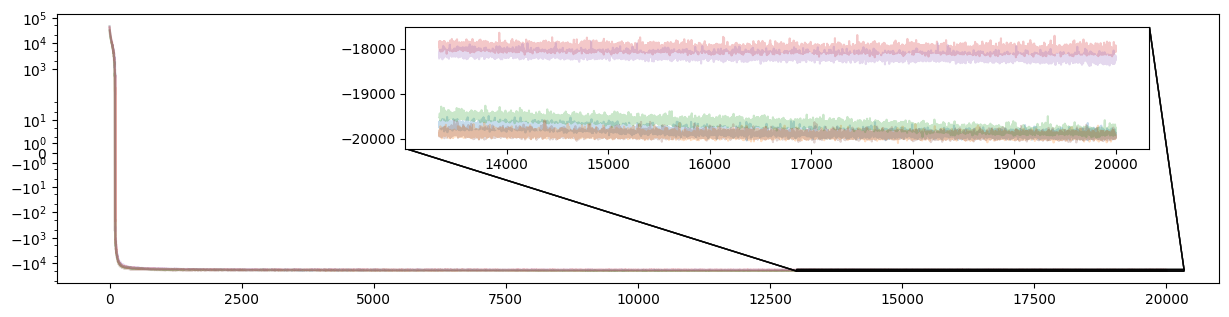

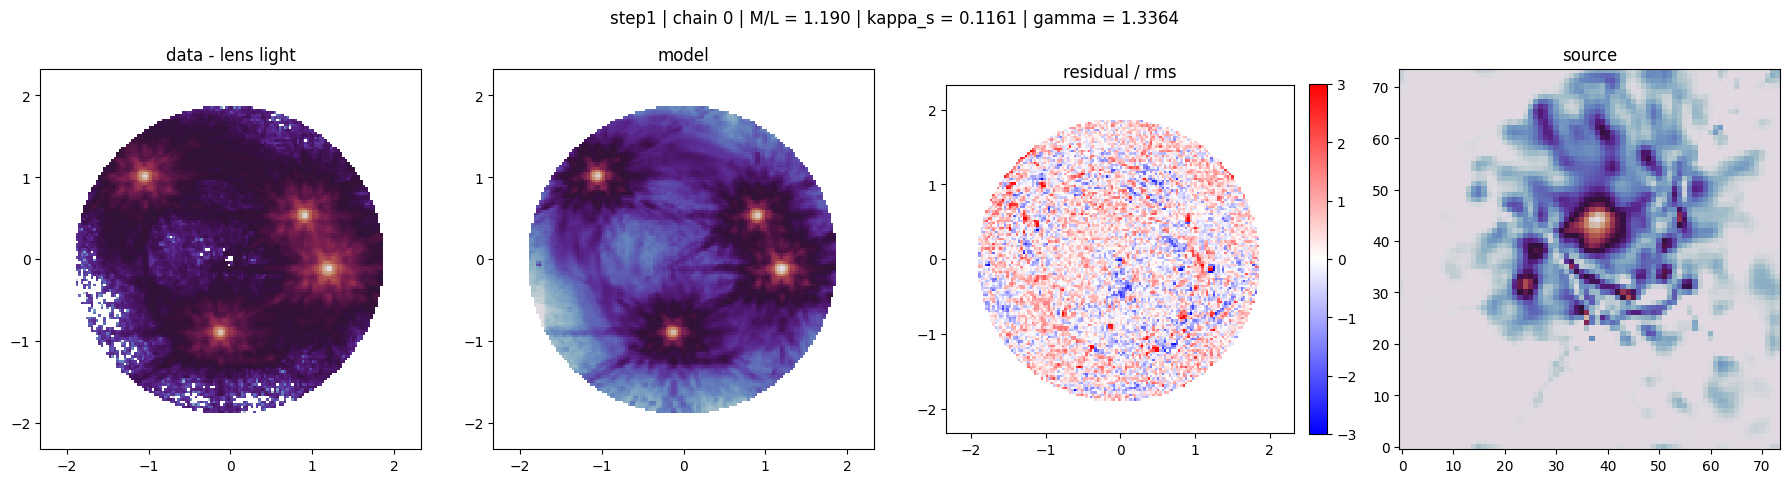

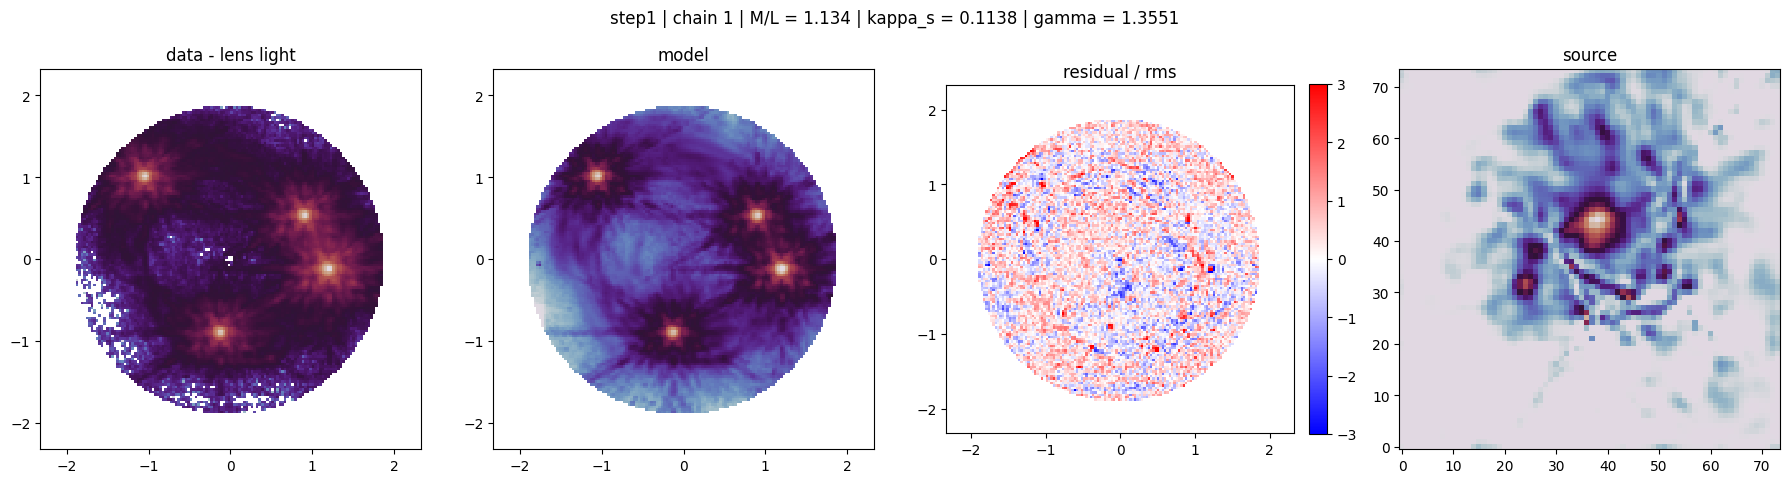

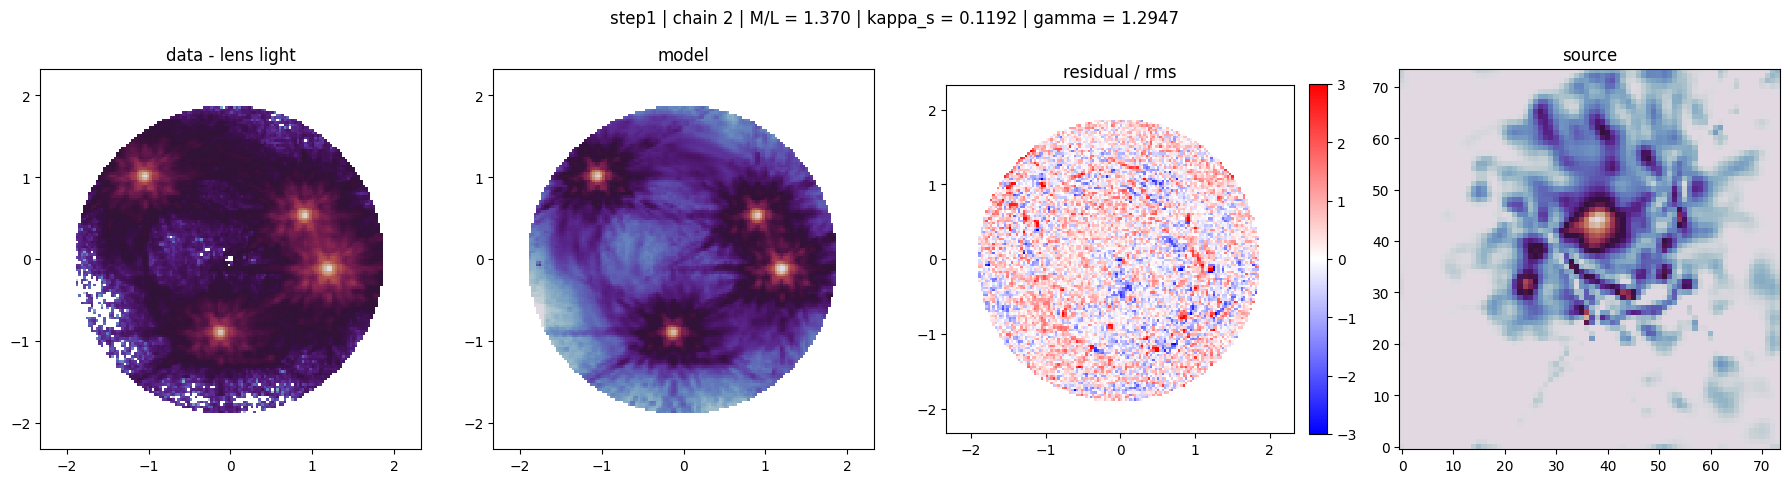

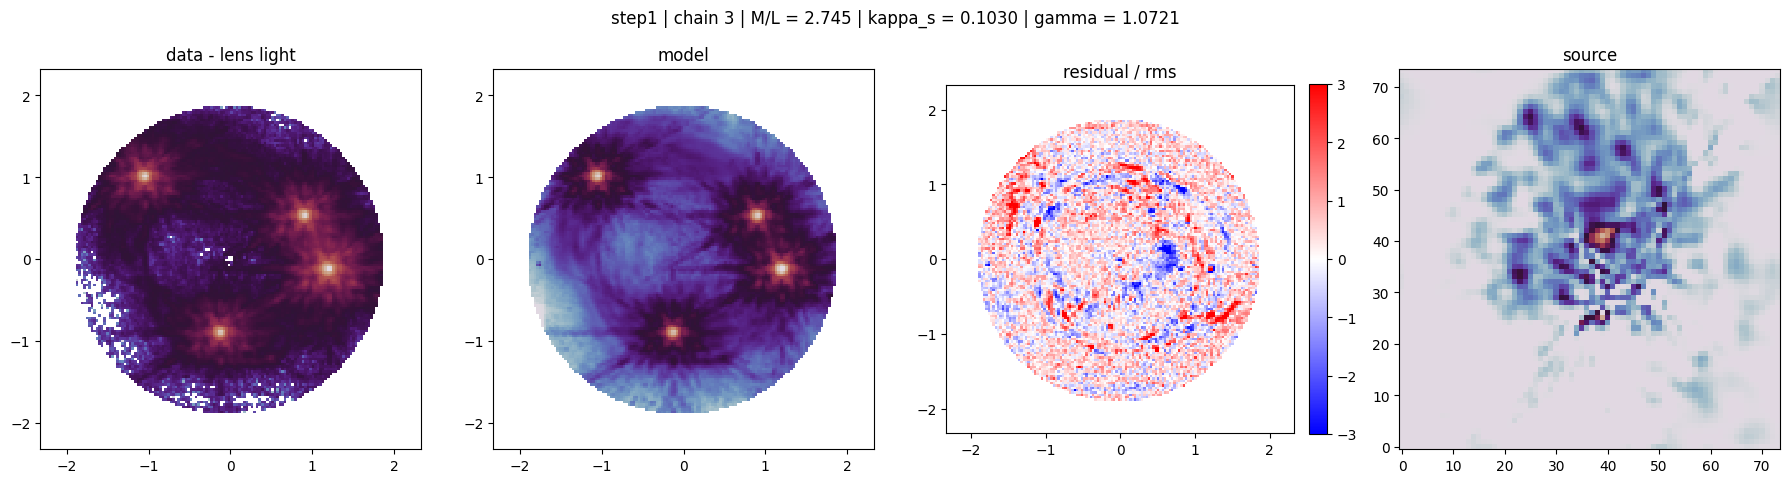

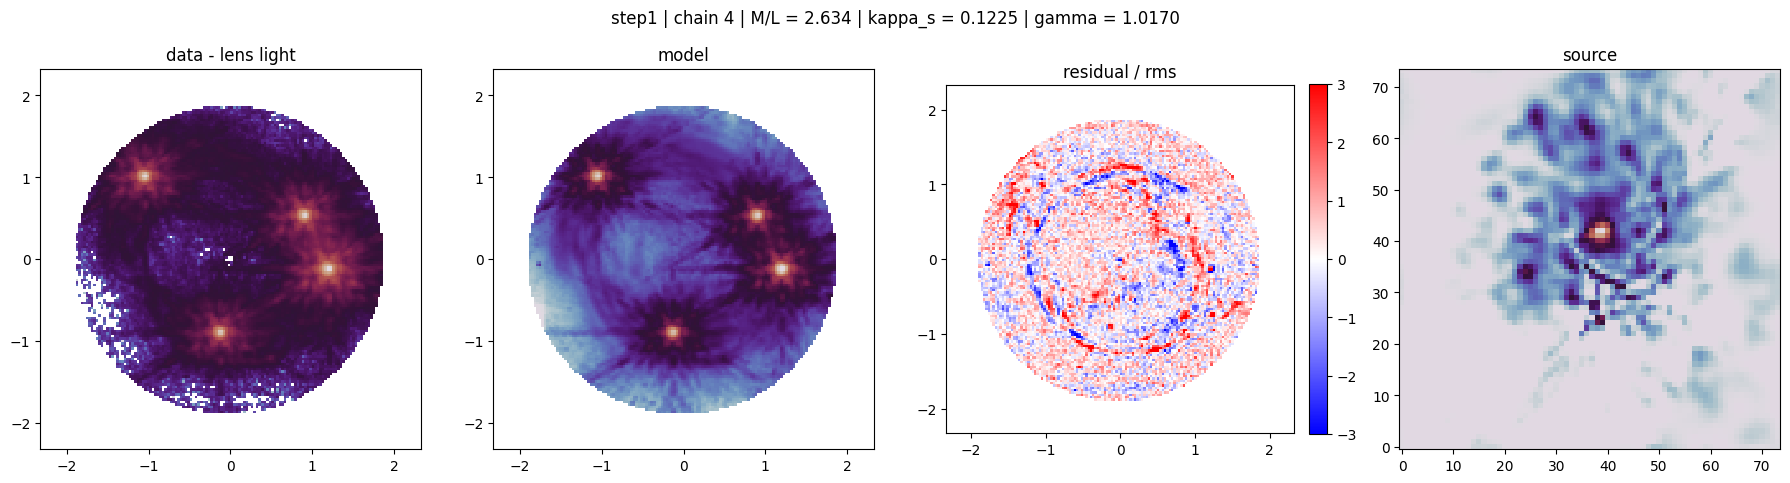

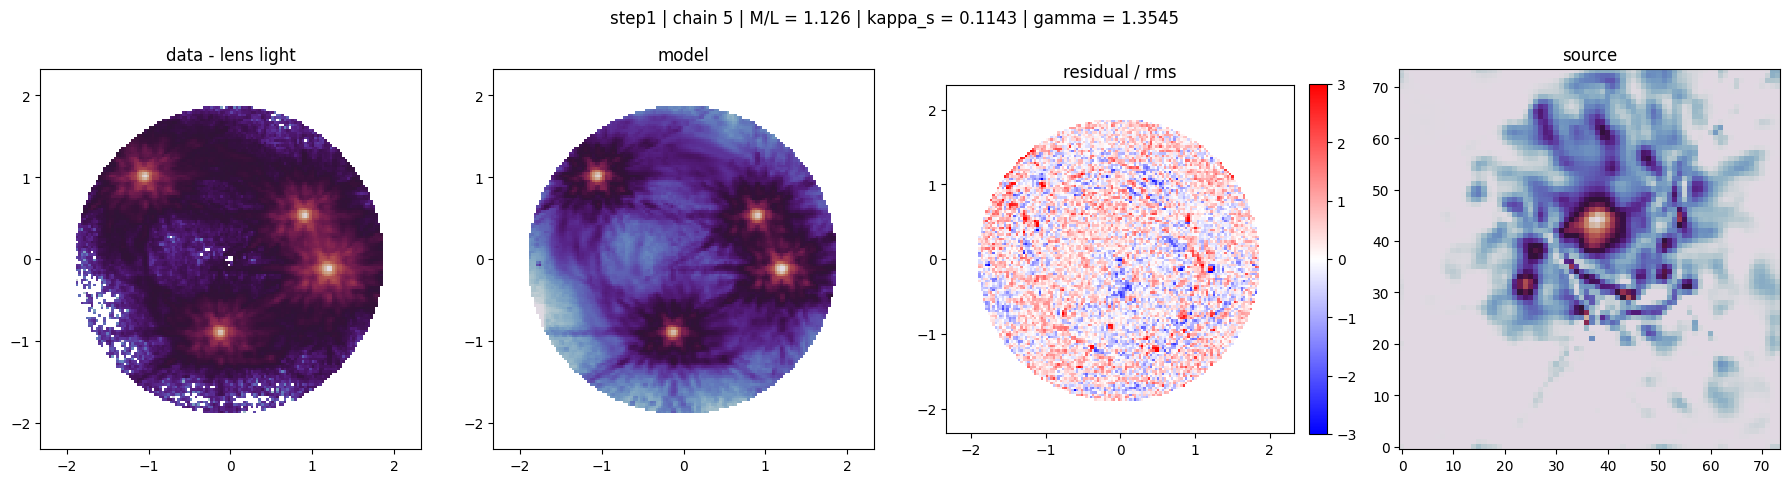

In [8]:
step1_output = run_stage(
    build_step1_stage_kwargs,
    init_builder=build_step1_init_values,
    max_iterations=20000,
    seed=1234,
)

plot_stage_losses(step1_output)
plot_stage_results(step1_output)


100%|██████████| 20000/20000 [01:31<00:00, 217.48it/s, init loss: 429848.0070, avg. loss [19001-20000]: -16648.1548]


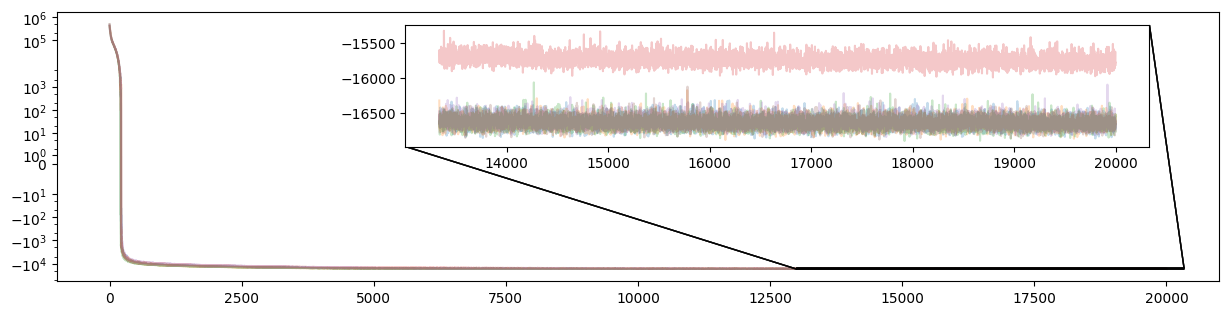

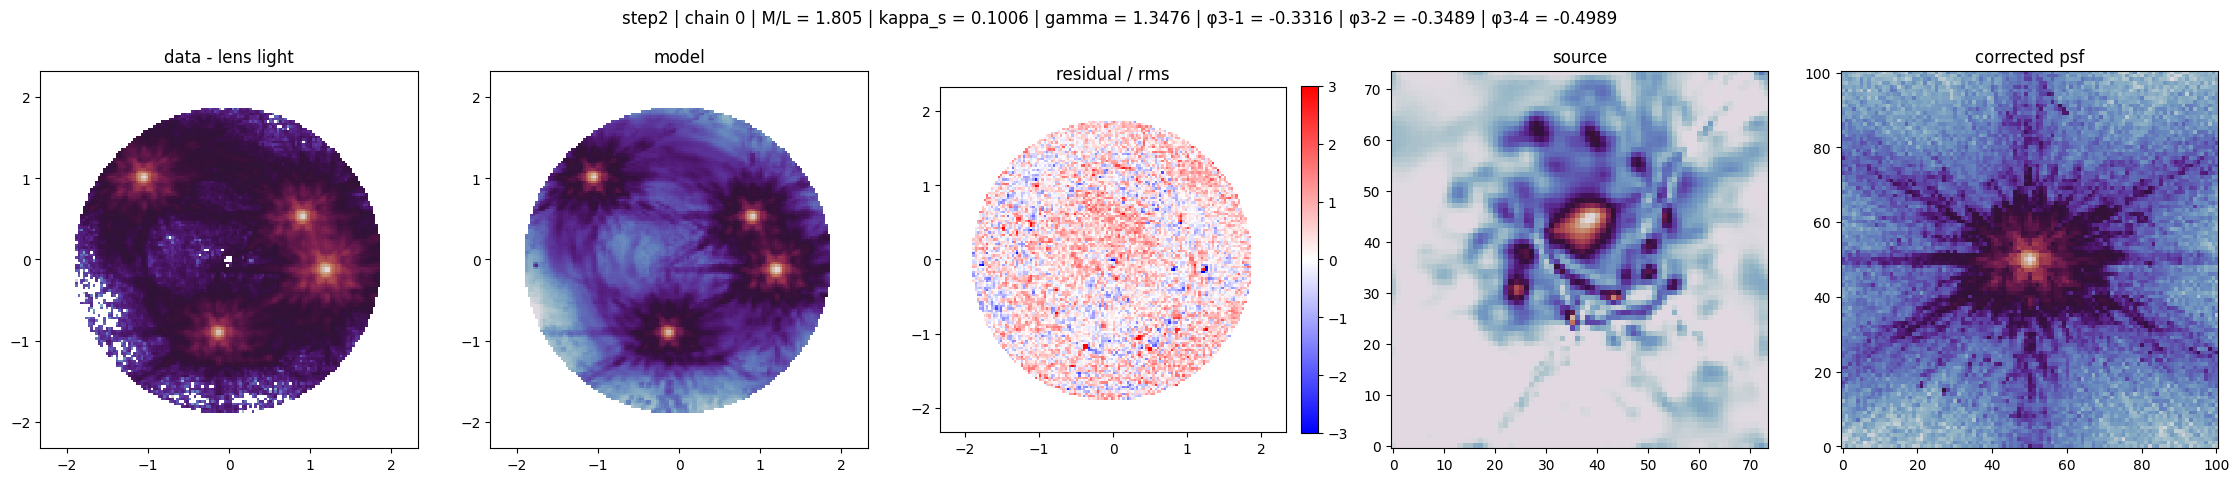

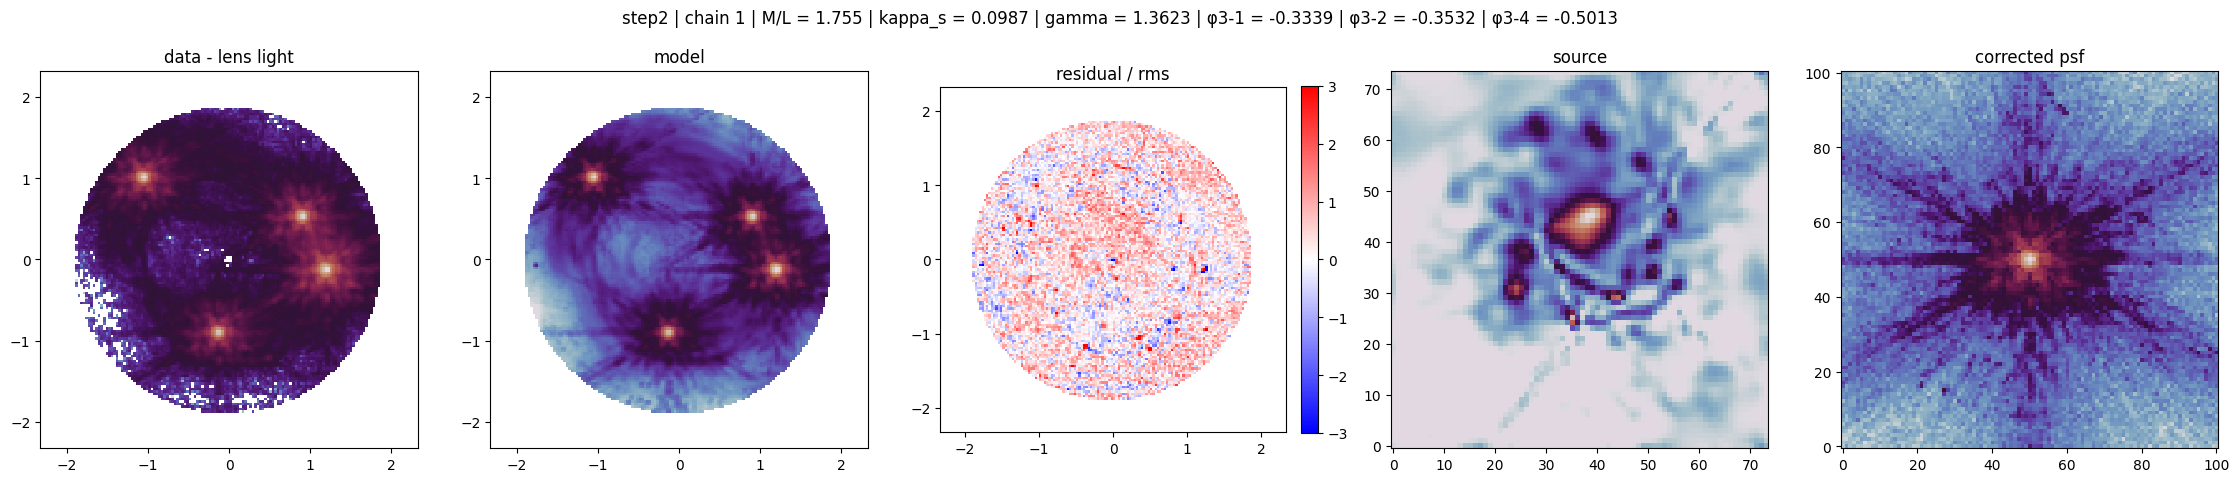

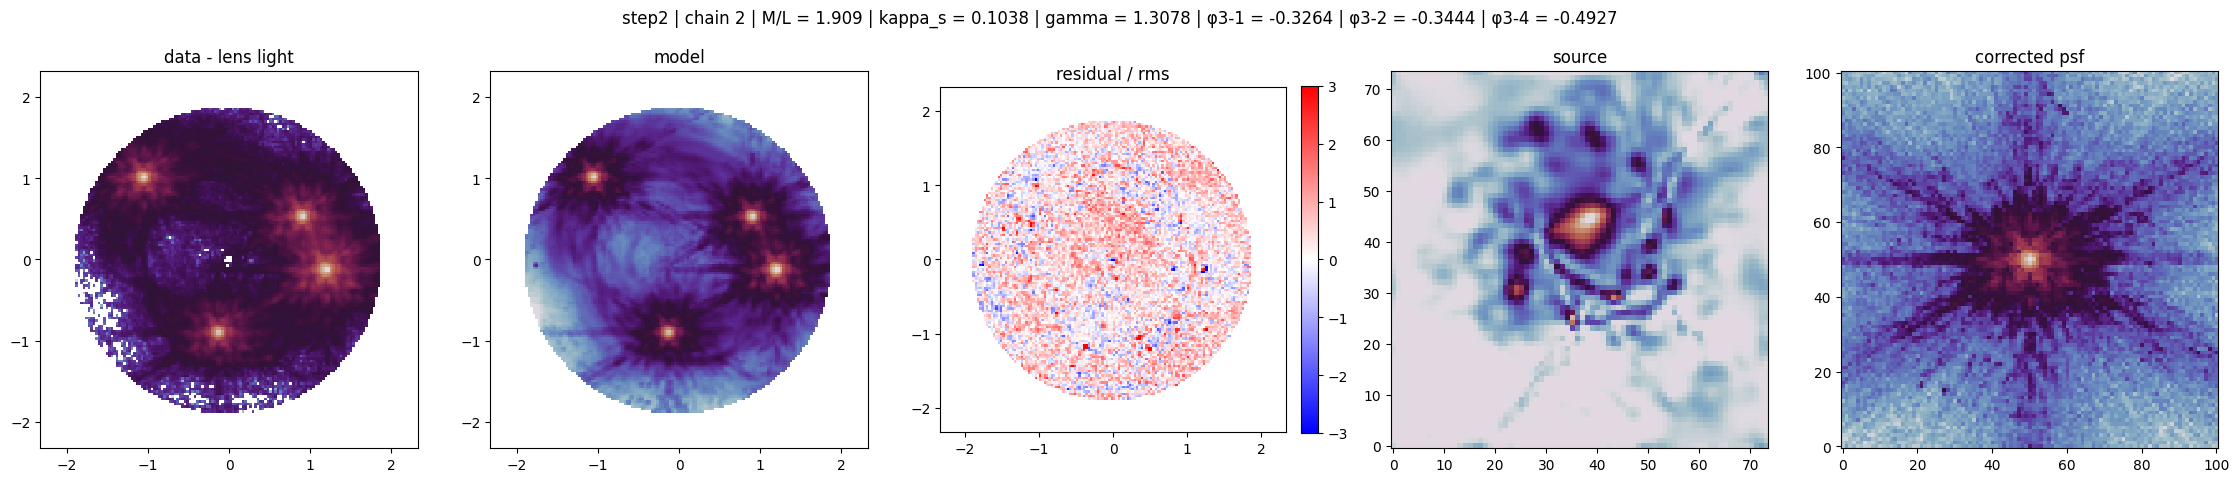

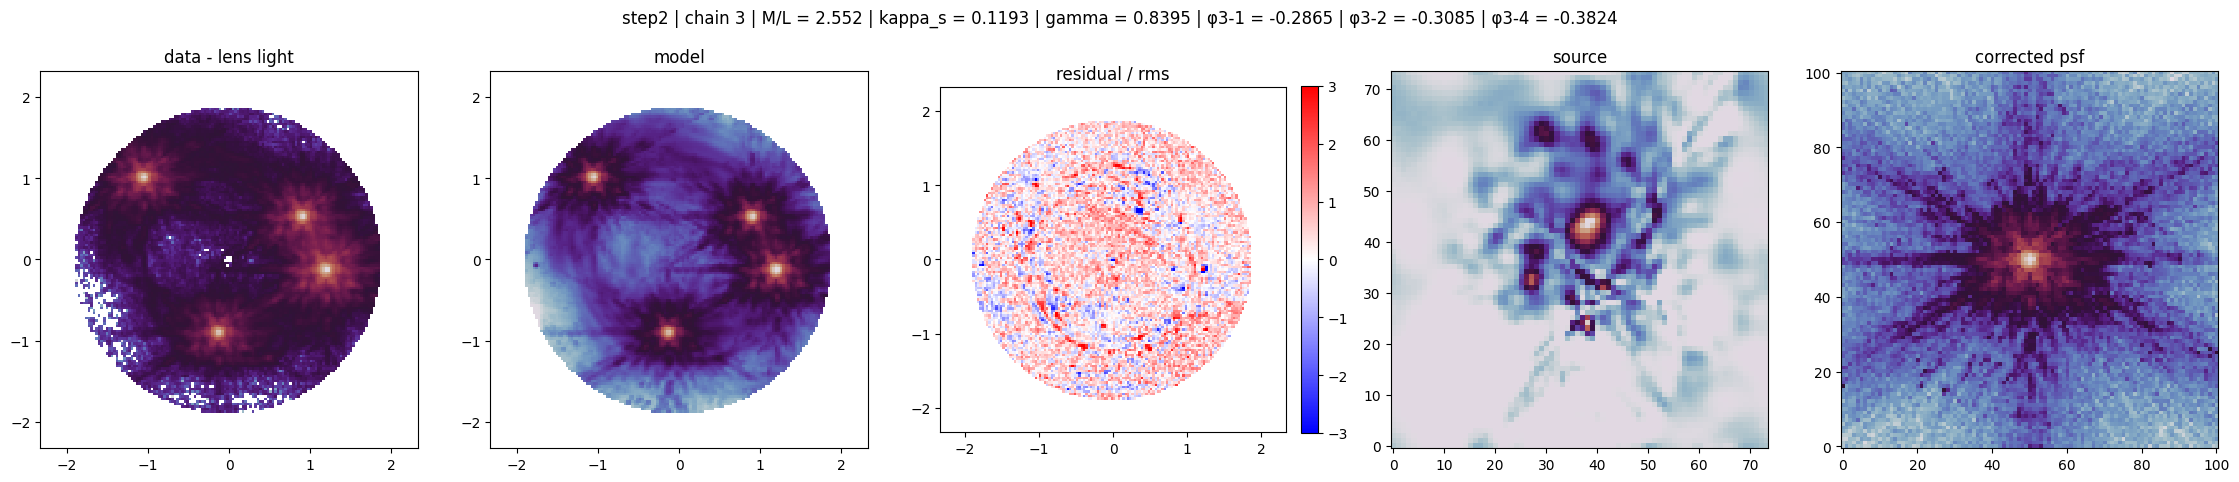

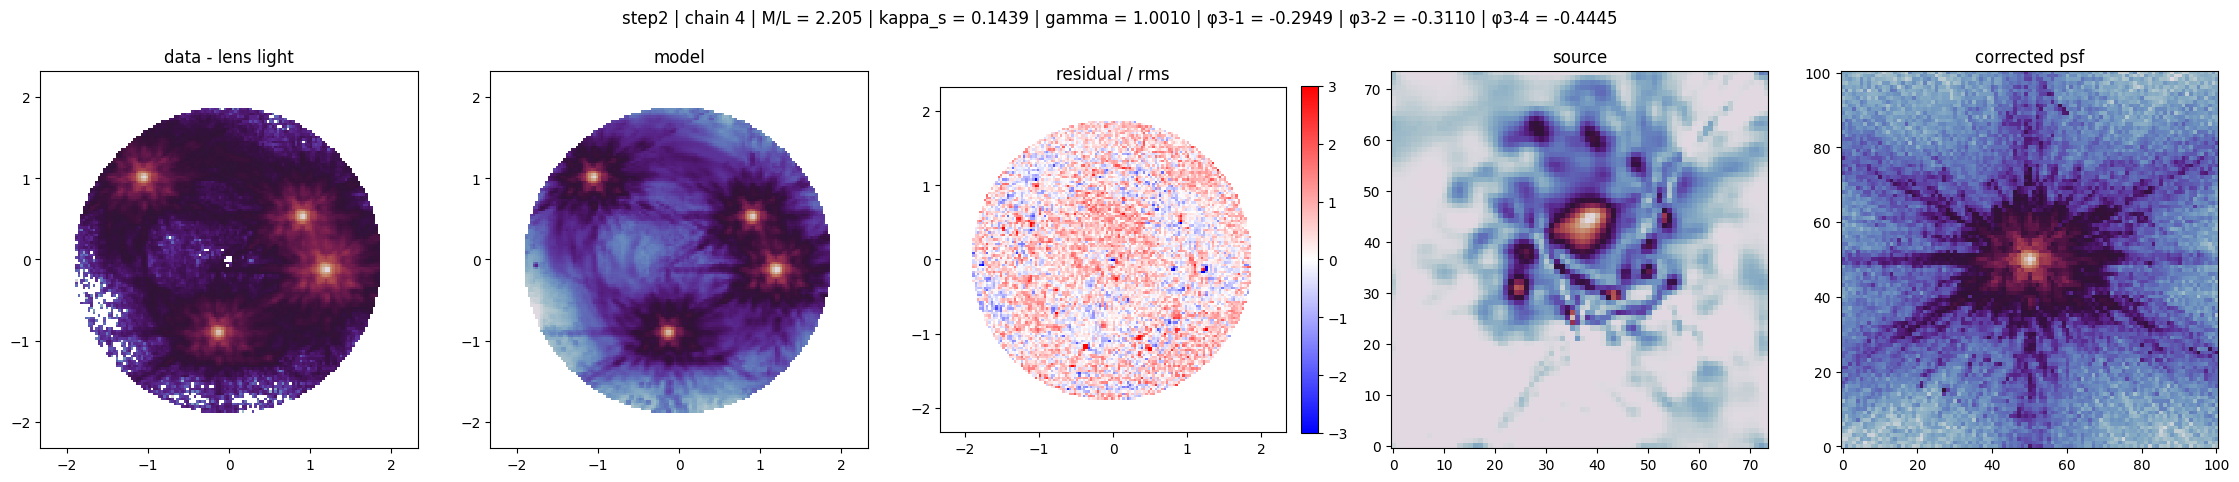

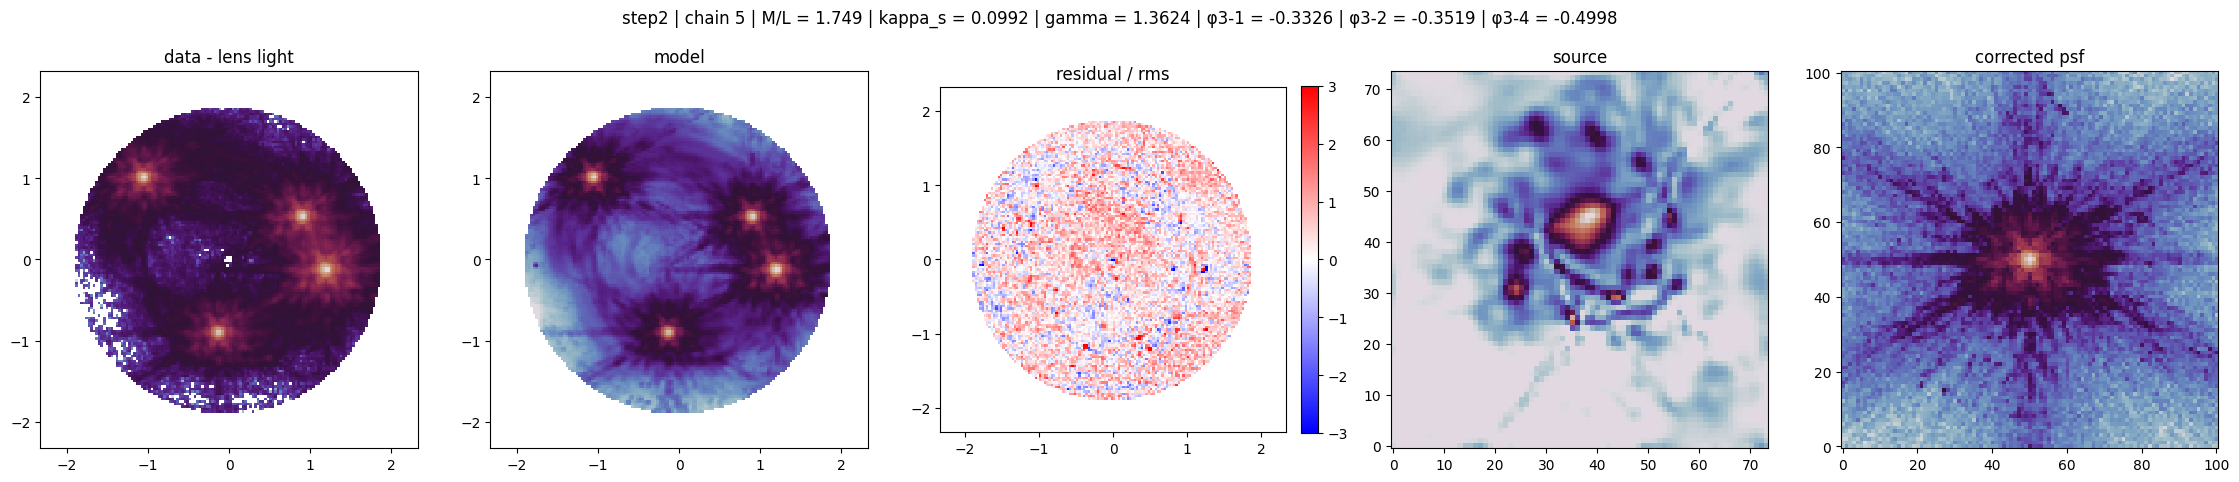

In [9]:
def build_step2_init_values(i):
    return dict(step1_output['medians'][i]) | build_step2_extra_init(i)


step2_output = run_stage(
    STEP2_KWARGS,
    init_builder=build_step2_init_values,
    max_iterations=20000,
    seed=2234,
)

plot_stage_losses(step2_output)
plot_stage_results(step2_output)


In [10]:
step1_medians = step1_output['medians']
step2_medians = step2_output['medians']
step2_medians

[{'m2l_ratio': Array(1.80546111, dtype=float64),
  'Rs_halo': Array(4.56242023, dtype=float64),
  'kappa_s_halo': Array(0.1006273, dtype=float64),
  'gammain_halo': Array(1.3476039, dtype=float64),
  'gamma_sheer_halo': Array([-0.01586761, -0.13231211], dtype=float64),
  'e_halo': Array([-0.09820638,  0.03527181], dtype=float64),
  'center_halo': Array([-0.04913247, -0.00696926], dtype=float64),
  'n_source_grid': Array([0.0005395], dtype=float64),
  'sigma_source_grid': Array([1.76632351], dtype=float64),
  'rho_source_grid': Array([1.762997], dtype=float64),
  'pixels_wn_source_grid': Array([[ 0.59219837, -2.96325467,  0.49689181, ...,  0.51028205,
           1.1034659 ,  0.71444649],
         [-2.46799602,  2.07029952, -0.04473591, ..., -0.97336252,
           0.84735668, -0.67473382],
         [ 0.67576098,  1.04575511,  0.44114426, ...,  1.50061273,
          -0.18728887, -0.14908016],
         ...,
         [-0.20918986,  0.00540202, -0.98162935, ...,  1.65800789,
          -1.37